In [1]:
import numpy as np



In [19]:
from multivae.data.datasets import MultimodalBaseDataset, DatasetOutput
from numpy import ndarray
from torch import Tensor
import scipy as sp
import torch

class copula_dataset(MultimodalBaseDataset):
    
    def __init__(self):
        self.mean = np.array([3,3,3,3])

        self.cov1 = np.zeros((4,4))
        self.cov2 = np.zeros((4,4))


        for i in range(4):
            for j in range(4):
                if i==j:
                    self.cov1[i,j] = 1
                    self.cov2[i,j] = 1
                else :
                    self.cov1[i,j] = (-1)**(i+j)*0.9
                    self.cov2[i,j] = 1*0.9
        
        self.x1 = np.random.multivariate_normal(self.mean, self.cov1,size=10000)
        self.x2 = np.random.multivariate_normal(self.mean, self.cov2,size=10000)
        
        
    def __getitem__(self, index):
        
        # print(self.x1.shape)
        # print(self.x1[index])
        
        x1 = sp.stats.norm.cdf(self.x1[index], loc=3, scale=1)
        x2 = sp.stats.norm.cdf(self.x2[index], loc=3, scale=1)
        
        # print(x1, x2)
        
        # x1 = self.x1[index]
        # x2 = self.x2[index]
        
        return DatasetOutput(data = 
            {f'mod{i}' : torch.from_numpy(np.array([x1[i],x2[i]])).float() for i in range(4)}
        )


    def __len__(self):
        return 1000
    
    



In [20]:
dataset = copula_dataset()

dataset[0]


DatasetOutput([('data',
                {'mod0': tensor([0.6148, 0.0623]),
                 'mod1': tensor([0.4731, 0.2124]),
                 'mod2': tensor([0.5320, 0.2592]),
                 'mod3': tensor([0.7854, 0.0538])})])

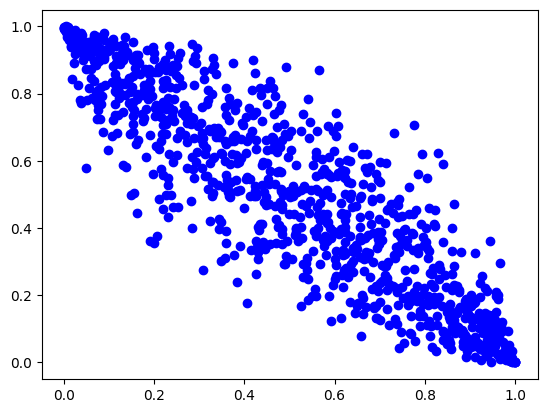

In [21]:
import matplotlib.pyplot as plt
plt.figure()
for i in range(1000):
    sample = dataset[i]
    plt.scatter(sample.data['mod0'][0],sample.data['mod1'][0], color='blue')

In [23]:
from pythae.models.nn.default_architectures import BaseEncoder, BaseDecoder, ModelOutput
from pythae.models.base import BaseAEConfig
from torch import nn

class Encoder_VAE_MLP(BaseEncoder):
    def __init__(self, args: dict):
        BaseEncoder.__init__(self)
        self.input_dim = args.input_dim
        self.latent_dim = args.latent_dim

        layers = nn.ModuleList()

        layers.append(nn.Sequential(nn.Linear(np.prod(args.input_dim), 256), nn.ReLU()))
        layers.append(nn.Sequential(nn.Linear(256, 256), nn.ReLU()))


        self.layers = layers
        self.depth = len(layers)

        self.embedding = nn.Linear(256, self.latent_dim)
        self.log_var = nn.Linear(256, self.latent_dim)

    def forward(self, x, output_layer_levels = None):
        output = ModelOutput()

        max_depth = self.depth

        if output_layer_levels is not None:

            assert all(
                self.depth >= levels > 0 or levels == -1
                for levels in output_layer_levels
            ), (
                f"Cannot output layer deeper than depth ({self.depth}). "
                f"Got ({output_layer_levels})."
            )

            if -1 in output_layer_levels:
                max_depth = self.depth
            else:
                max_depth = max(output_layer_levels)

        out = x.reshape(-1, np.prod(self.input_dim))

        for i in range(max_depth):
            out = self.layers[i](out)

            if output_layer_levels is not None:
                if i + 1 in output_layer_levels:
                    output[f"embedding_layer_{i+1}"] = out
            if i + 1 == self.depth:
                output["embedding"] = self.embedding(out)
                output["log_covariance"] = self.log_var(out)

        return output
    
    
class Decoder_AE_MLP(BaseDecoder):
    # The same as in Pythae but allows for any input shape (*, latent_dim) with * containing any number of dimensions.
    def __init__(self, args: dict):
        BaseDecoder.__init__(self)

        self.input_dim = args.input_dim

        layers = nn.ModuleList()

        layers.append(nn.Sequential(nn.Linear(args.latent_dim, 256), nn.ReLU()))
        layers.append(nn.Sequential(nn.Linear(256, 256), nn.ReLU()))


        layers.append(
            nn.Sequential(nn.Linear(256, int(np.prod(args.input_dim))), nn.Sigmoid())
        )

        self.layers = layers
        self.depth = len(layers)

    def forward(self, z: torch.Tensor):
        output = ModelOutput()

        max_depth = self.depth
        out = z

        for i in range(max_depth):
            out = self.layers[i](out)
            if i + 1 == self.depth:
                output_shape = (*z.shape[:-1],) + self.input_dim
                output["reconstruction"] = out.reshape(output_shape)

        return output


In [24]:
from multivae.models import JNF, JNFConfig

model_config = JNFConfig(
    n_modalities=4,
    input_dims=dict(
        mod0 = (2,),
        mod1 = (2,),
        mod2 = (2,),
        mod3 = (2,)
    ),
    warmup = 20,
    latent_dim=3,
    beta=2.5
)

encoders = {f'mod{i}' : Encoder_VAE_MLP(BaseAEConfig((2,),model_config.latent_dim)) for i in range(4)}
decoders = {f'mod{i}' : Decoder_AE_MLP(BaseAEConfig(input_dim=(2,), latent_dim=model_config.latent_dim)) for i in range(4)}

model = JNF(model_config, encoders=encoders, decoders=decoders)

print(model.encoders.keys())
model(sample)




odict_keys(['mod0', 'mod1', 'mod2', 'mod3'])


ModelOutput([('loss', tensor(3.9503, grad_fn=<DivBackward0>)),
             ('metrics',
              {'kld_prior': tensor(0.0070, grad_fn=<MulBackward0>),
               'recon_loss': tensor(3.9467, grad_fn=<DivBackward0>),
               'ljm': 0})])

In [25]:
from multivae.trainers import TwoStepsTrainer, TwoStepsTrainerConfig

trainer_config  = TwoStepsTrainerConfig(
    num_epochs=40
)

trainer = TwoStepsTrainer(
    model=model,train_dataset=dataset,training_config=trainer_config
)

trainer.train()

! No eval dataset provided ! -> keeping best model on train.

Model passed sanity check !
Ready for training.

Setting the optimizer with learning rate 0.0001
Created dummy_output_dir/JNF_training_2024-09-13_16-40-31. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 40
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Training of epoch 1/40: 100%|██████████| 16/16 [00:00<00:00, 22.96batch/s]
--------------------------------------------------------------------------
Train loss: 7.691
--------------------------------------------------------------------------
Training of epoch 2/40: 100%|██████████| 16/16 [00:

In [26]:
embeddings = model.generate_from_prior(500)

generated_samples = model.decode(embeddings)

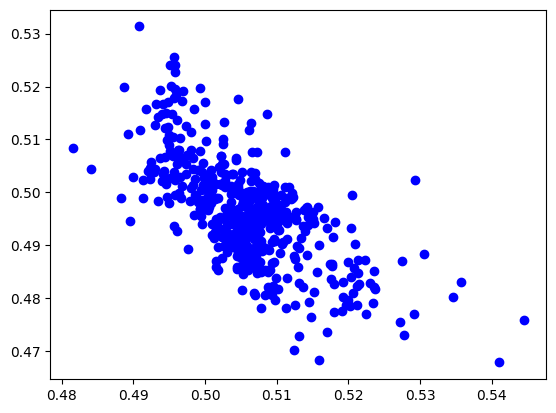

In [27]:
import matplotlib.pyplot as plt
plt.figure()
for i in range(500):
    
    plt.scatter(generated_samples['mod0'][i].detach().numpy()[0],generated_samples['mod1'][i].detach().numpy()[0], color='blue')

In [3]:
# Load trained jnf model and visualize generated samples

from multivae.models import AutoModel

model = AutoModel.load_from_folder('/home/asenella/dev/multivae_package/dummy_output_dir/JNF_training_2024-09-13_17-31-59/final_model')

/home/asenella/dev/multivae_package/multimodal_vaes/src/multivae/models/base/base_model.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(path

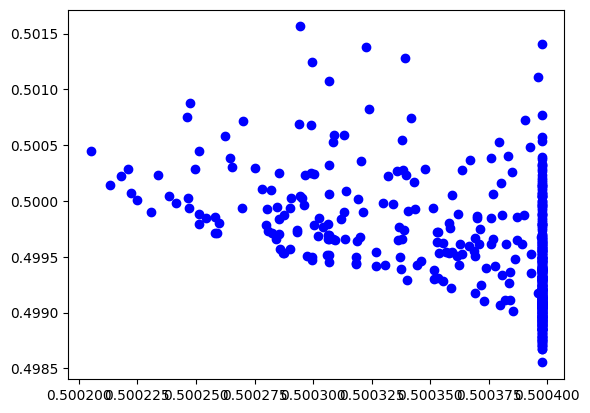

In [5]:

embeddings = model.generate_from_prior(500)

generated_samples = model.decode(embeddings)

import matplotlib.pyplot as plt
plt.figure()
for i in range(500):
    
    plt.scatter(generated_samples['mod0'][i].detach().cpu().numpy()[0],generated_samples['mod1'][i].detach().cpu().numpy()[0], color='blue')
    


In [6]:
# Load trained jnf model and visualize generated samples

from multivae.models import AutoModel

model = AutoModel.load_from_folder('/home/asenella/dev/multivae_package/dummy_output_dir/MoPoE_training_2024-09-13_17-18-49/final_model')

/home/asenella/dev/multivae_package/multimodal_vaes/src/multivae/models/base/base_model.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(path

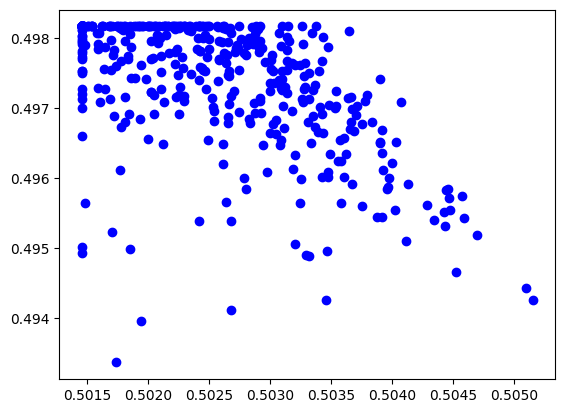

In [7]:

embeddings = model.generate_from_prior(500)

generated_samples = model.decode(embeddings)

import matplotlib.pyplot as plt
plt.figure()
for i in range(500):
    
    plt.scatter(generated_samples['mod0'][i].detach().cpu().numpy()[0],generated_samples['mod1'][i].detach().cpu().numpy()[0], color='blue')
    
